# **Day 85: Capstone - An End-to-End ML Project, and AutoML**
*Module 12 - Trustworthy ML and MLOps*

Before the remote-sensing projects, we run **one complete project** from question to deliverable, using the professional workflow of the whole course. Then we look at **AutoML**: what it automates, how to build a simple version, and what it cannot do for us.

**The task: digital soil mapping.** Predict **soil organic carbon (SOC, %)** at unsampled locations from environmental covariates (terrain, climate, vegetation, land use, parent material). SOC maps support carbon accounting and soil-health programmes.

**Workflow** (each step links back to the day that taught it):
1. Problem framing and success criteria (Day 1, 15)
2. Data audit and EDA (Day 6, 17)
3. Honest validation design: **spatial blocks** (Day 16, 40)
4. Baselines (Day 15, 25)
5. Pipelines and candidate models (Day 20-38)
6. Tuning with nested validation (Day 41)
7. Statistical comparison (Day 42)
8. Final evaluation with uncertainty (Day 25, 77)
9. Interpretation and error analysis (Day 44-45)
10. Model card and saving (Day 78, 82)
11. AutoML (bonus)

> The capstone brings everything together in one end-to-end project: defining the problem, preparing data, comparing models, tuning, explaining, evaluating and packaging the final model. AutoML automates part of the model search.
>
> *Example:* From a raw table of field samples to a validated, saved crop classifier with a short report, the full workflow is in one notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, time, json, joblib
from scipy.ndimage import gaussian_filter
from sklearn.model_selection import GroupKFold, cross_val_predict, cross_val_score
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
import lightgbm as lgb
warnings.filterwarnings("ignore", category=UserWarning)
rng = np.random.default_rng(85)

## **1. Problem Framing**

| Item | Decision |
|---|---|
| Target | SOC (%) in topsoil 0-30 cm (continuous, positive, right-skewed) |
| Unit | one soil sample location (point) |
| Use | wall-to-wall map for a 60 x 60 km region; must be reliable **away from sampled sites** |
| Metric | RMSE and R^2 (also MAE, bias); with 95% CIs; **spatial** cross-validation |
| Baseline to beat | regional mean; linear model on covariates |
| Constraint | covariates must be available everywhere as rasters |

## **2. Simulating a Realistic Study Area**
SOC depends on elevation (cooler, wetter uplands store more carbon), rainfall, NDVI (inputs of organic matter), land use (forest > grassland > cropland), parent material, plus spatially autocorrelated unexplained variation. Samples are **clustered** near roads (as in real surveys).

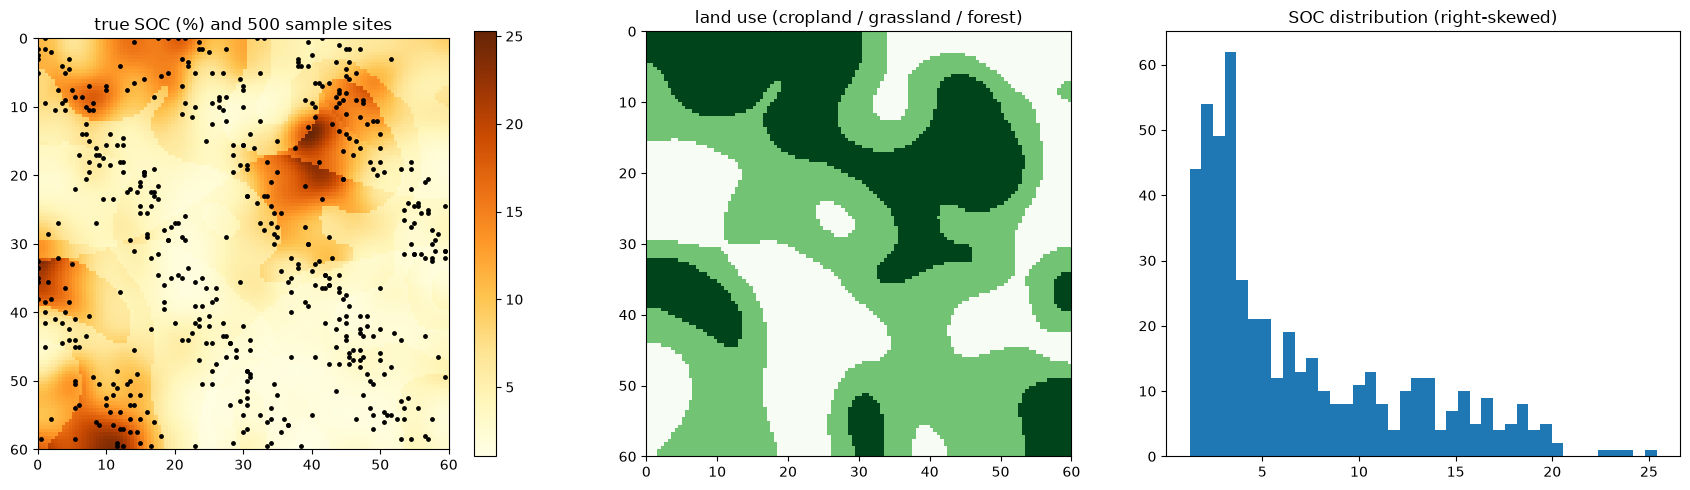

In [2]:
G = 120                                                                          # 120 x 120 cells of 500 m = 60 km
smooth = lambda s: (lambda a: (a - a.mean()) / a.std())(gaussian_filter(rng.normal(size=(G, G)), s))
elev = 300 + 600 * (smooth(15) + 1.5).clip(0); rain = 1200 + 300 * smooth(20) + 0.3 * (elev - 600); ndvi = (0.5 + 0.15 * smooth(6)).clip(0.05, 0.9)
landuse = np.digitize(smooth(8), [-0.5, 0.6]); landuse_names = np.array(["cropland", "grassland", "forest"])
parent = np.digitize(smooth(25), [-0.3, 0.4]); parent_names = np.array(["alluvium", "granite", "basalt"])
residual_field = 0.25 * smooth(5)
log_soc = (-0.9 + 0.0009 * elev + 0.0004 * rain + 1.1 * ndvi + np.array([0.0, 0.25, 0.6])[landuse] + np.array([0.0, -0.1, 0.2])[parent] + residual_field)
soc_true = np.exp(log_soc)

road_cells = np.argwhere(np.abs(np.add.outer(np.arange(G) * 0.6, -np.arange(G)) % 40) < 2)       # diagonal roads
near = road_cells[rng.choice(len(road_cells), 350)] + rng.integers(-6, 7, (350, 2)); far = rng.integers(0, G, (150, 2))
pts = np.clip(np.vstack([near, far]), 0, G - 1)
r_, c_ = pts[:, 0], pts[:, 1]
df = pd.DataFrame({"x_km": c_ * 0.5, "y_km": r_ * 0.5, "elevation_m": elev[r_, c_], "rainfall_mm": rain[r_, c_], "ndvi": ndvi[r_, c_],
                   "landuse": landuse_names[landuse[r_, c_]], "parent_material": parent_names[parent[r_, c_]],
                   "soc_pct": soc_true[r_, c_] * rng.lognormal(0, 0.12, len(pts))})       # lab measurement noise
df.loc[rng.random(len(df)) < 0.04, "rainfall_mm"] = np.nan                                 # some missing covariates
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
im = axes[0].imshow(soc_true, cmap="YlOrBr", extent=[0, 60, 60, 0]); axes[0].scatter(df.x_km, df.y_km, s=6, c="k"); axes[0].set_title("true SOC (%) and 500 sample sites"); fig.colorbar(im, ax=axes[0])
axes[1].imshow(landuse, cmap="Greens", extent=[0, 60, 60, 0]); axes[1].set_title("land use (cropland / grassland / forest)")
axes[2].hist(df.soc_pct, bins=40); axes[2].set_title("SOC distribution (right-skewed)")
plt.tight_layout(); plt.show()

## **3. Data Audit and EDA**

In [3]:
print(df.describe().round(2).T[["count", "mean", "std", "min", "max"]])
print("\nmissing values:\n", df.isna().sum()[df.isna().sum() > 0])
print("\nmean SOC by land use:\n", df.groupby("landuse").soc_pct.agg(["mean", "count"]).round(2))
num = ["elevation_m", "rainfall_mm", "ndvi"]
print("\nSpearman correlation with SOC:\n", df[num + ["soc_pct"]].corr(method="spearman").soc_pct.round(3))

             count     mean     std     min      max
x_km         500.0    29.32   16.93    0.00    59.50
y_km         500.0    30.00   17.64    0.00    59.50
elevation_m  500.0  1203.34  580.89  300.00  2388.37
rainfall_mm  476.0  1373.27  319.62  687.72  2493.05
ndvi         500.0     0.51    0.15    0.12     0.90
soc_pct      500.0     6.90    5.31    1.24    25.40

missing values:
 rainfall_mm    24
dtype: int64

mean SOC by land use:
             mean  count
landuse                
cropland    3.56    125
forest     10.98    151
grassland   6.02    224

Spearman correlation with SOC:
 elevation_m    0.838
rainfall_mm    0.317
ndvi           0.118
soc_pct        1.000
Name: soc_pct, dtype: float64


## **4. Validation Design: Spatial Blocks**
Samples are clustered and SOC is spatially autocorrelated, so a random K-fold would test the model on near-copies of its training points. We use **spatial block CV**: 10 km blocks, grouped folds (Day 40). We also keep a final **untouched test region**: all samples in 4 randomly chosen blocks.

In [4]:
df["block"] = (df.x_km // 10).astype(int) * 10 + (df.y_km // 10).astype(int)
test_blocks = rng.choice(df.block.unique(), 4, replace=False)
test = df[df.block.isin(test_blocks)].copy(); dev = df[~df.block.isin(test_blocks)].copy()
features = ["elevation_m", "rainfall_mm", "ndvi", "landuse", "parent_material"]
X, y, groups = dev[features], dev.soc_pct, dev.block
cv = GroupKFold(5)
print(f"development set {len(dev)} samples in {dev.block.nunique()} blocks | test set {len(test)} samples in 4 held-out blocks")

development set 428 samples in 32 blocks | test set 72 samples in 4 held-out blocks


## **5. Baselines and Candidate Models (all as pipelines)**

In [5]:
prep_linear = ColumnTransformer([("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), ["elevation_m", "rainfall_mm", "ndvi"]),
                                 ("cat", OneHotEncoder(handle_unknown="ignore"), ["landuse", "parent_material"])])
prep_tree = ColumnTransformer([("num", SimpleImputer(strategy="median"), ["elevation_m", "rainfall_mm", "ndvi"]),
                               ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), ["landuse", "parent_material"])])
log_t = lambda reg: TransformedTargetRegressor(reg, func=np.log, inverse_func=np.exp)            # model log(SOC): skewed, multiplicative
candidates = {"mean (baseline)": DummyRegressor(),
              "ridge on log(SOC)": log_t(Pipeline([("prep", prep_linear), ("m", RidgeCV(np.logspace(-3, 3, 20)))])),
              "random forest": Pipeline([("prep", prep_tree), ("m", RandomForestRegressor(500, min_samples_leaf=3, random_state=0, n_jobs=-1))]),
              "hist gradient boosting (log)": log_t(Pipeline([("prep", prep_tree), ("m", HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, categorical_features=[3, 4], random_state=0))])),
              "LightGBM (log)": log_t(Pipeline([("prep", prep_tree), ("m", lgb.LGBMRegressor(n_estimators=400, learning_rate=0.03, num_leaves=15, min_child_samples=10, verbose=-1, random_state=0))]))}
rows, fold_scores = [], {}
for name, model in candidates.items():
    s = cross_val_score(model, X, y, groups=groups, cv=cv, scoring="neg_root_mean_squared_error"); fold_scores[name] = -s
    pred = cross_val_predict(model, X, y, groups=groups, cv=cv)
    rows.append({"model": name, "spatial-CV RMSE": -s.mean(), "RMSE sd over folds": s.std(), "R2": r2_score(y, pred), "bias": np.mean(pred - y)})
pd.DataFrame(rows).set_index("model").round(3)

,spatial-CV RMSE,RMSE sd over folds,R2,bias
model,,,,
mean (baseline),5.572,0.668,-0.048,0.001
ridge on log(SOC),2.570,0.283,0.777,-0.415
random forest,3.408,1.131,0.573,-0.410
hist gradient boosting (log),2.713,1.005,0.722,-0.704
LightGBM (log),2.924,0.808,0.695,-0.536


Compare with what a (wrong) **random** K-fold would claim:

In [6]:
from sklearn.model_selection import KFold
rf_rand = cross_val_score(candidates["random forest"], X, y, cv=KFold(5, shuffle=True, random_state=0), scoring="r2").mean()
rf_spat = cross_val_score(candidates["random forest"], X, y, groups=groups, cv=cv, scoring="r2").mean()
print(f"random forest R2: random 5-fold {rf_rand:.3f} vs spatial block CV {rf_spat:.3f}")

random forest R2: random 5-fold 0.843 vs spatial block CV 0.556


## **6. Tuning With Nested Spatial CV**
Tune LightGBM's main hyperparameters with Optuna inside each outer fold (inner spatial CV), so the reported score is not optimistically biased (Day 40-41).

In [7]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
def tuned_lgbm(X_in, y_in, g_in, n_trials=15, seed=0):
    def objective(trial):
        p = {"n_estimators": trial.suggest_int("n_estimators", 100, 600, step=100), "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
             "num_leaves": trial.suggest_int("num_leaves", 4, 31, log=True), "min_child_samples": trial.suggest_int("min_child_samples", 5, 40),
             "subsample": trial.suggest_float("subsample", 0.6, 1.0), "subsample_freq": 1, "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0)}
        m = log_t(Pipeline([("prep", prep_tree), ("m", lgb.LGBMRegressor(**p, verbose=-1, random_state=seed))]))
        return -cross_val_score(m, X_in, y_in, groups=g_in, cv=GroupKFold(4), scoring="neg_root_mean_squared_error").mean()
    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=seed)); study.optimize(objective, n_trials=n_trials)
    best = {**study.best_params, "subsample_freq": 1}
    return log_t(Pipeline([("prep", prep_tree), ("m", lgb.LGBMRegressor(**best, verbose=-1, random_state=seed))])).fit(X_in, y_in), best
t0 = time.perf_counter(); outer = []
for k, (tr, va) in enumerate(cv.split(X, y, groups)):
    m, best = tuned_lgbm(X.iloc[tr], y.iloc[tr], groups.iloc[tr], seed=k)
    outer.append(root_mean_squared_error(y.iloc[va], m.predict(X.iloc[va])))
fold_scores["LightGBM tuned (nested)"] = np.array(outer)
print(f"nested spatial CV RMSE of tuned LightGBM: {np.mean(outer):.3f} +/- {np.std(outer):.3f} ({time.perf_counter() - t0:.0f}s) | untuned {fold_scores['LightGBM (log)'].mean():.3f}")

nested spatial CV RMSE of tuned LightGBM: 2.951 +/- 0.743 (19s) | untuned 2.924


## **7. Is the Best Model Really Better? (Day 42)**

In [8]:
from scipy import stats
def corrected_t(a, b, n_train_frac=0.8):
    d = a - b; J = len(d); t = d.mean() / np.sqrt((1 / J + (1 - n_train_frac) / n_train_frac) * d.var(ddof=1)); return d.mean(), 2 * stats.t.sf(abs(t), J - 1)
for other in ["ridge on log(SOC)", "random forest", "hist gradient boosting (log)"]:
    diff, p = corrected_t(fold_scores[other], fold_scores["LightGBM tuned (nested)"])
    print(f"{other:<30} RMSE minus tuned LightGBM = {diff:+.3f}, corrected p = {p:.3f}")

ridge on log(SOC)              RMSE minus tuned LightGBM = -0.381, corrected p = 0.516
random forest                  RMSE minus tuned LightGBM = +0.456, corrected p = 0.223
hist gradient boosting (log)   RMSE minus tuned LightGBM = -0.238, corrected p = 0.684


With only 5 spatial folds, differences between the tree ensembles are usually **not** significant. A defensible choice: the simplest model within noise of the best, or a tuned boosting model if its gain is consistent. We take the tuned LightGBM, refitted on all development data.

## **8. Final Evaluation on the Untouched Test Blocks, With Uncertainty**

TEST (4 unseen blocks, n = 72): R2 0.731 [95% CI 0.558, 0.842] | RMSE 1.790 [1.253, 2.331] % SOC | bias -0.654


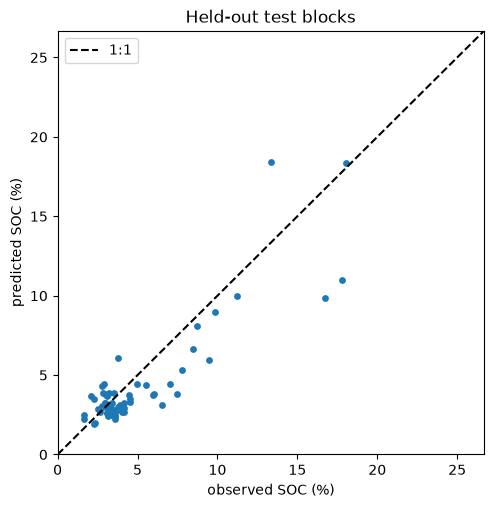

In [9]:
final, best_params = tuned_lgbm(X, y, groups, n_trials=25, seed=42)
pred_test = final.predict(test[features])
boot = []
for _ in range(2000):
    i = rng.integers(0, len(test), len(test)); boot.append([r2_score(test.soc_pct.values[i], pred_test[i]), root_mean_squared_error(test.soc_pct.values[i], pred_test[i])])
boot = np.array(boot)
print(f"TEST (4 unseen blocks, n = {len(test)}): R2 {r2_score(test.soc_pct, pred_test):.3f} [95% CI {np.percentile(boot[:, 0], 2.5):.3f}, {np.percentile(boot[:, 0], 97.5):.3f}] | "
      f"RMSE {root_mean_squared_error(test.soc_pct, pred_test):.3f} [{np.percentile(boot[:, 1], 2.5):.3f}, {np.percentile(boot[:, 1], 97.5):.3f}] % SOC | bias {np.mean(pred_test - test.soc_pct):+.3f}")
lim = [0, df.soc_pct.max() * 1.05]
plt.figure(figsize=(5.5, 5.5)); plt.scatter(test.soc_pct, pred_test, s=15); plt.plot(lim, lim, "k--", label="1:1"); plt.xlim(lim); plt.ylim(lim)
plt.xlabel("observed SOC (%)"); plt.ylabel("predicted SOC (%)"); plt.legend(); plt.title("Held-out test blocks"); plt.show()

## **9. Interpretation, Error Analysis and the Map**

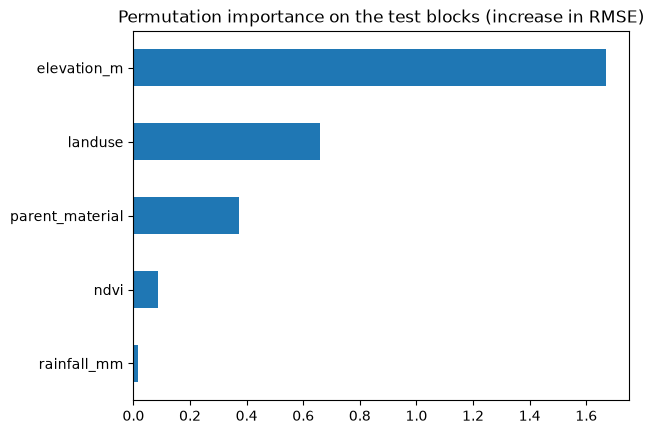

mean absolute error by land use:
 landuse
cropland     0.545
forest       2.816
grassland    1.232
Name: abs_err, dtype: float64


In [10]:
from sklearn.inspection import permutation_importance
pi = permutation_importance(final, test[features], test.soc_pct, n_repeats=20, random_state=0, scoring="neg_root_mean_squared_error")
pd.Series(pi.importances_mean, index=features).sort_values().plot.barh(title="Permutation importance on the test blocks (increase in RMSE)"); plt.show()
err = test.assign(abs_err=np.abs(pred_test - test.soc_pct))
print("mean absolute error by land use:\n", err.groupby("landuse").abs_err.mean().round(3))

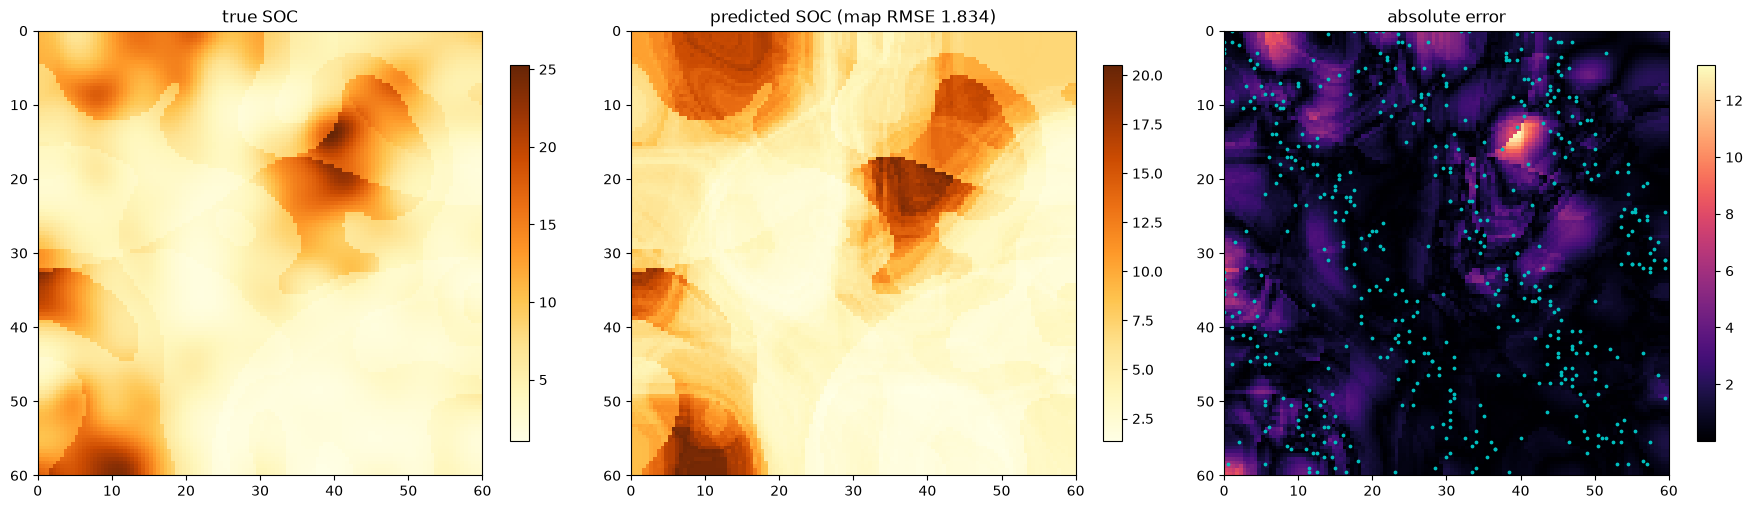

Spearman correlation between map error and distance to nearest sample: 0.096


In [11]:
grid_df = pd.DataFrame({"elevation_m": elev.ravel(), "rainfall_mm": rain.ravel(), "ndvi": ndvi.ravel(),
                        "landuse": landuse_names[landuse.ravel()], "parent_material": parent_names[parent.ravel()]})
soc_map = final.predict(grid_df).reshape(G, G)
from sklearn.neighbors import NearestNeighbors
dist_to_sample = NearestNeighbors(n_neighbors=1).fit(df[["y_km", "x_km"]].values / 0.5).kneighbors(np.argwhere(np.ones((G, G))))[0].reshape(G, G) * 0.5
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, img_, t, cm in [(axes[0], soc_true, "true SOC", "YlOrBr"), (axes[1], soc_map, f"predicted SOC (map RMSE {root_mean_squared_error(soc_true.ravel(), soc_map.ravel()):.3f})", "YlOrBr"),
                        (axes[2], np.abs(soc_map - soc_true), "absolute error", "magma")]:
    im = ax.imshow(img_, cmap=cm, extent=[0, 60, 60, 0]); ax.set_title(t); fig.colorbar(im, ax=ax, shrink=0.8)
axes[2].scatter(df.x_km, df.y_km, s=3, c="c"); plt.tight_layout(); plt.show()
print(f"Spearman correlation between map error and distance to nearest sample: {pd.Series(np.abs(soc_map - soc_true).ravel()).corr(pd.Series(dist_to_sample.ravel()), method='spearman'):.3f}")

## **10. Model Card and Saving**

In [12]:
card = {"model": "LightGBM on log(SOC) with median imputation and ordinal-encoded categoricals", "version": "1.0.0", "target": "SOC % (0-30 cm)",
        "covariates": features, "training samples": int(len(dev)), "validation": "5-fold spatial block CV (10 km blocks) + 4 held-out test blocks",
        "hyperparameters": {k: (round(v, 4) if isinstance(v, float) else v) for k, v in best_params.items()},
        "test R2": round(r2_score(test.soc_pct, pred_test), 3), "test RMSE": round(root_mean_squared_error(test.soc_pct, pred_test), 3),
        "limitations": ["sampling clustered near roads; errors grow with distance from samples", "covariate rasters must match training sources",
                        "not valid outside the covariate ranges of the training data (see area of applicability, Day 88)"]}
joblib.dump(final, "soc_model_v1.joblib"); open("soc_model_v1.json", "w").write(json.dumps(card, indent=2))
print(json.dumps(card, indent=1))

{
 "model": "LightGBM on log(SOC) with median imputation and ordinal-encoded categoricals",
 "version": "1.0.0",
 "target": "SOC % (0-30 cm)",
 "covariates": [
  "elevation_m",
  "rainfall_mm",
  "ndvi",
  "landuse",
  "parent_material"
 ],
 "training samples": 428,
 "validation": "5-fold spatial block CV (10 km blocks) + 4 held-out test blocks",
 "hyperparameters": {
  "n_estimators": 600,
  "learning_rate": 0.0459,
  "num_leaves": 11,
  "min_child_samples": 33,
  "subsample": 0.6248,
  "colsample_bytree": 0.5737,
  "subsample_freq": 1
 },
 "test R2": 0.731,
 "test RMSE": 1.79,
 "limitations": [
  "sampling clustered near roads; errors grow with distance from samples",
  "covariate rasters must match training sources",
  "not valid outside the covariate ranges of the training data (see area of applicability, Day 88)"
 ]
}


# **Part 2: AutoML**

**AutoML** automates model selection, preprocessing choices and hyperparameter tuning (and sometimes ensembling), within a time budget. Popular systems: **auto-sklearn** (Bayesian optimisation + meta-learning + ensembles), **FLAML** (cost-aware search), **AutoGluon** (multi-layer stacking of many models), **H2O AutoML**, TPOT. Below is a compact AutoML built with Optuna: the **model family itself** is a hyperparameter, evaluated with our spatial CV.

In [13]:
def automl(X_in, y_in, g_in, n_trials=40, seed=0):
    def build(trial):
        fam = trial.suggest_categorical("family", ["ridge", "rf", "lgbm", "hgb"])
        if fam == "ridge": return log_t(Pipeline([("prep", prep_linear), ("m", RidgeCV(np.logspace(-3, 3, 20)))]))
        if fam == "rf": return Pipeline([("prep", prep_tree), ("m", RandomForestRegressor(300, max_features=trial.suggest_float("rf_max_features", 0.3, 1.0), min_samples_leaf=trial.suggest_int("rf_leaf", 1, 10), random_state=0, n_jobs=-1))])
        if fam == "lgbm": return log_t(Pipeline([("prep", prep_tree), ("m", lgb.LGBMRegressor(n_estimators=trial.suggest_int("lgb_n", 100, 600, step=100), learning_rate=trial.suggest_float("lgb_lr", 0.01, 0.1, log=True), num_leaves=trial.suggest_int("lgb_leaves", 4, 31, log=True), min_child_samples=trial.suggest_int("lgb_mcs", 5, 40), verbose=-1, random_state=0))]))
        return log_t(Pipeline([("prep", prep_tree), ("m", HistGradientBoostingRegressor(max_iter=trial.suggest_int("hgb_iter", 100, 500, step=100), learning_rate=trial.suggest_float("hgb_lr", 0.01, 0.2, log=True), max_leaf_nodes=trial.suggest_int("hgb_leaves", 4, 31, log=True), categorical_features=[3, 4], random_state=0))]))
    def objective(trial):
        return -cross_val_score(build(trial), X_in, y_in, groups=g_in, cv=GroupKFold(5), scoring="neg_root_mean_squared_error").mean()
    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=seed)); study.optimize(objective, n_trials=n_trials)
    return study, build(study.best_trial).fit(X_in, y_in)
t0 = time.perf_counter(); study, auto_model = automl(X, y, groups)
trials = study.trials_dataframe()
print(f"AutoML: {len(trials)} trials in {time.perf_counter() - t0:.0f}s | best family {study.best_params['family']} | spatial-CV RMSE {study.best_value:.3f}")
print(f"AutoML model on the test blocks: RMSE {root_mean_squared_error(test.soc_pct, auto_model.predict(test[features])):.3f} (hand-built: {root_mean_squared_error(test.soc_pct, pred_test):.3f})")
print(trials.groupby("params_family").value.agg(["min", "count"]).round(3).rename(columns={"min": "best RMSE", "count": "trials"}))

AutoML: 40 trials in 18s | best family ridge | spatial-CV RMSE 2.570
AutoML model on the test blocks: RMSE 1.352 (hand-built: 1.790)
               best RMSE  trials
params_family                   
hgb                2.670       5
lgbm               2.805       6
rf                 3.297       6
ridge              2.570      23


### What AutoML does not do for us
AutoML optimises **whatever validation we give it**. With random K-fold on clustered spatial data it would happily select the most overfitted model. It does not frame the question, check data quality, choose the sampling design, prevent leakage, judge physical plausibility, or write the limitations. Use it as a strong **baseline generator**, not as a substitute for the workflow above.

## **Practice Problems**
1. Re-run the model comparison with random 5-fold CV instead of spatial blocks. Does the ranking of models change?
2. Add the coordinates (`x_km`, `y_km`) as features. Does spatial CV improve? What happens in the test blocks? (Coordinates let a model interpolate locally but they do not transfer.)
3. Produce a 90% prediction-interval map using conformalised quantile regression (Day 77) with spatial calibration blocks.
4. *(Advanced)* Run the AutoML with random K-fold as the objective, then evaluate its chosen model on the test blocks. Is it worse than the spatial-CV AutoML choice?

In [14]:
# Solution 1
for name in ["ridge on log(SOC)", "random forest", "LightGBM (log)"]:
    print(f"{name:<22} random-CV RMSE {-cross_val_score(candidates[name], X, y, cv=KFold(5, shuffle=True, random_state=0), scoring='neg_root_mean_squared_error').mean():.3f} | spatial-CV {fold_scores[name].mean():.3f}")
# Solution 2
feats_xy = features + ["x_km", "y_km"]
prep_xy = ColumnTransformer([("num", SimpleImputer(strategy="median"), ["elevation_m", "rainfall_mm", "ndvi", "x_km", "y_km"]), ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), ["landuse", "parent_material"])])
m_xy = log_t(Pipeline([("prep", prep_xy), ("m", lgb.LGBMRegressor(**best_params, verbose=-1, random_state=0))]))
print(f"with coordinates: spatial-CV RMSE {-cross_val_score(m_xy, dev[feats_xy], y, groups=groups, cv=cv, scoring='neg_root_mean_squared_error').mean():.3f} | "
      f"test RMSE {root_mean_squared_error(test.soc_pct, m_xy.fit(dev[feats_xy], y).predict(test[feats_xy])):.3f}")

ridge on log(SOC)      random-CV RMSE 2.272 | spatial-CV 2.570


random forest          random-CV RMSE 2.150 | spatial-CV 3.408


LightGBM (log)         random-CV RMSE 2.021 | spatial-CV 2.924


with coordinates: spatial-CV RMSE 2.939 | test RMSE 1.797


## **Key References**
- Hengl, T. et al. (2017). SoilGrids250m: Global gridded soil information based on machine learning. *PLOS ONE*, 12(2), e0169748.
- McBratney, A. B., Mendonca Santos, M. L., & Minasny, B. (2003). On digital soil mapping. *Geoderma*, 117(1-2), 3-52.
- Wadoux, A. M. J.-C., Minasny, B., & McBratney, A. B. (2020). Machine learning for digital soil mapping: Applications, challenges and suggested solutions. *Earth-Science Reviews*, 210, 103359.
- Feurer, M. et al. (2015). Efficient and robust automated machine learning. *NeurIPS 28* (auto-sklearn).
- Erickson, N. et al. (2020). AutoGluon-Tabular: Robust and accurate AutoML for structured data. arXiv:2003.06505.
- Wang, C., Wu, Q., Weimer, M., & Zhu, E. (2021). FLAML: A fast and lightweight AutoML library. *MLSys 2021*.
- Ploton, P. et al. (2020). Spatial validation reveals poor predictive performance of large-scale ecological mapping models. *Nature Communications*, 11, 4540.